# 04 - Fixed volt-var controllers over the year

Notebook 03 produced one year of PV and load profiles for the CIGRE European MV feeder
(CIGRE TB 575, Section 6.2) with the nine PV units of Wagle et al. (6.44 MW on feeder 1,
TR1 at +4.375 %), screened every 15-minute step at unity power factor, and found about
200 hours above 1.05 pu, all at midday on sunny days and all at the two far ends of
feeder 1. This notebook asks two questions of the standard remedy, the volt-var curve of
IEEE 1547-2018 that every inverter can run on its own terminal voltage: how well do the
standard curves do over the year, and how far are they from what a feeder-wide optimum
could achieve with the same nine units?

Five fixed controllers are run over the whole year, and a per-step optimal power flow
(OPF) that knows the whole feeder is run on a sample of days as the bound:

| id | controller | reactive power | active power |
|----|-----------|----------------|--------------|
| B0 | unity power factor (no control) | 0 | Pmpp times irradiance |
| B1 | IEEE 1547-2018 Category B default volt-var | (0.92, +0.44), (0.98, 0), (1.02, 0), (1.08, -0.44) | unchanged |
| B2 | B1 plus the IEEE 1547-2018 default volt-watt | as B1 | 1.0 pu at 1.06 pu down to 0.2 pu at 1.10 pu |
| B3 | tight volt-var, same curve at every unit | (0.92, +0.44), (0.98, 0), (1.00, 0), (1.04, -0.44) | unchanged |
| B4 | lazy volt-var, same curve at every unit | (0.92, +0.44), (0.98, 0), (1.03, 0), (1.10, -0.44) | unchanged |
| B5 | per-step OPF over the nine Q setpoints (bound) | minimises losses + penalty on buses outside the band + small weight on the sum of abs(Q) | unchanged |

Q is in pu of the inverter kVA. The study configuration is the one fixed in notebooks 02
and 03: TR1 at +4.375 % on the 20 kV side, so that the feeder without PV is inside 0.95 to
1.05 pu at every step of the year and every violation is attributable to PV, and an
inverter rating of 1.1 Pmpp, so that 0.44 pu of kVA (about 0.48 Pmpp) is available at
full active output (sqrt(1.1^2 - 0.44^2) = 1.008 > 1).

The controllers are compared on the same key performance indicators (KPIs): hours with
any bus outside the band, a voltage performance index, annual losses, curtailed PV
energy, and the reactive energy absorbed and injected, counted separately. Two modules
are introduced for this and reused by the following notebooks: `simulate.py` (the
time-series loop, the InvControl helpers and the OPF controller) and `kpi.py` (the KPIs).

Steps:

1. The IEEE 1547-2018 curves and how OpenDSS implements them.
2. The KPIs.
3. The simulation loop.
4. Controllers B0 to B4 over the full year: KPI table.
5. The year in figures: duration curves and daily reactive energy.
6. The worst day, 2023-07-22.
7. The OPF bound B5 on 32 sampled days: formulation and KPI table.
8. B1 against B5 on the worst day, and where the reactive power goes.
9. KPI bars.
10. Save `baselines_2023.h5` and `baselines_2023.json`.
11. Summary.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import json, time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import opendssdirect as dss

import cigre_dss as cd
import simulate as sim
import kpi

TR1_TAP = 4.375                 # % on the 20 kV side, fixed in notebook 02
assert sim.TR1_TAP_PCT == TR1_TAP and sim.KVA_RATIO == 1.1
YEAR = 2023
PV_BUSES, PV_KW, PV_KVA = sim.PV_BUSES, sim.PV_KW, sim.PV_KVA
F1 = sim.F1_BUSES               # buses 1 .. 11
DT_H = sim.DT_H
SPD = int(24 / DT_H)            # steps per day

pv, loads, attrs = sim.load_year("profiles_2023.h5")
sel = json.load(open("selected_days_2023.json"))
DAY_WORST, DAY_TYPICAL = sel["worst_day"], sel["typical_day"]
T = len(pv)
h = np.arange(0, 24, DT_H)      # solar hour within a day

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9})
def legend_below(ax, ncol=3, dy=-0.15):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, dy), ncol=ncol, frameon=False)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
MONTH_DATES = [pd.Timestamp(YEAR, m, 1) for m in range(1, 13)]

print("opendssdirect", dss.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print(f"year {attrs['year']}, {T} steps of {int(DT_H * 60)} min | worst day {DAY_WORST}, typical day {DAY_TYPICAL}")
print(f"TR1 tap +{TR1_TAP} %, {len(PV_BUSES)} PV units, {PV_KW.sum() / 1e3:.2f} MW, kVA = {sim.KVA_RATIO} x Pmpp "
      f"({PV_KVA.sum() / 1e3:.2f} MVA)")

opendssdirect 0.9.4 | pandas 2.3.3 | numpy 2.4.6
year 2023, 35040 steps of 15 min | worst day 2023-07-22, typical day 2023-09-14
TR1 tap +4.375 %, 9 PV units, 6.44 MW, kVA = 1.1 x Pmpp (7.08 MVA)


## 1. The IEEE 1547-2018 curves

**Volt-var (Clause 5.3.3).** The DER absorbs or injects reactive power as a piecewise
linear function of its terminal voltage. Table 8 gives the Category B default curve, with
$V_\mathrm{ref} = 1$ pu:

| point | V, pu | Q, pu of nameplate kVA |
|---|---|---|
| (V1, Q1) | 0.92 | +0.44 (injecting) |
| (V2, Q2) | 0.98 | 0 |
| (V3, Q3) | 1.02 | 0 |
| (V4, Q4) | 1.08 | -0.44 (absorbing) |

Between V2 and V3 the unit does nothing (the dead band); outside it the reactive power
ramps linearly to the clamp of 0.44 pu, which the standard requires to be available at
full active output. The standard allows the four points to be moved within ranges (V3
from V_ref to V_ref + 0.03, V4 from V3 to V_ref + 0.18, and so on) and specifies an
open-loop response time of 5 s by default (adjustable from 1 to 90 s). With 15-minute
steps that response is over well within a step, so each step here is the settled state.

Three volt-var curves are used. The **default** curve is the table above. The **tight**
curve pulls the upper points down to V3 = 1.00 and V4 = 1.04, so that absorption starts
as soon as the voltage rises above nominal and reaches the clamp at 1.04 pu. The
**lazy** curve pushes them up to V3 = 1.03 and V4 = 1.10, so that absorption starts late
and the clamp is reached only above the limit. All three keep the lower half of the
default curve. The lazy curve is included because it matters later: it is the fixed curve
that a learned, per-unit adjustment of the curve points has to beat.

**Volt-watt (Clause 5.4.2).** The DER reduces its active power above a voltage
threshold. Table 10 gives the default curve, P = 1.0 pu of rated power up to 1.06 pu and
falling linearly to 0.2 pu at 1.10 pu; the function is required but *disabled* by
default, and it is enabled here in B2 to see whether it ever acts once the volt-var curve
is active.

**Implementation in OpenDSS.** Each curve is an `XYCurve`; one `InvControl` element
applies it to all nine `PVSystem` elements, in `mode=voltvar` (B1, B3, B4) or
`combimode=VV_VW` (B2). `voltage_curvex_ref=rated` makes the x axis the terminal voltage
in pu of the 20 kV rating. The y axis is Q in pu of the inverter kVA: OpenDSS's own
default reference is the vars *available* at the current P (`refreactivepower=varaval`),
which at full output would shrink 0.44 to about 0.18 of kVA, so `refreactivepower=varmax`
is set explicitly (`kvarmax` defaults to the kVA). `deltaq_factor=-1` (and
`deltap_factor=-1` for volt-watt) lets OpenDSS choose the damping of its control
iteration. With `controlmode=static` the solver alternates power flow and curve
evaluation at every step until no unit changes its setpoint, i.e. it iterates to the
fixed point of curve and network; if that takes more than `maxcontroliter=200` rounds,
the step is counted as a control-loop failure. The figure shows the three volt-var curves
and the volt-watt curve with the 1.05 pu limit.

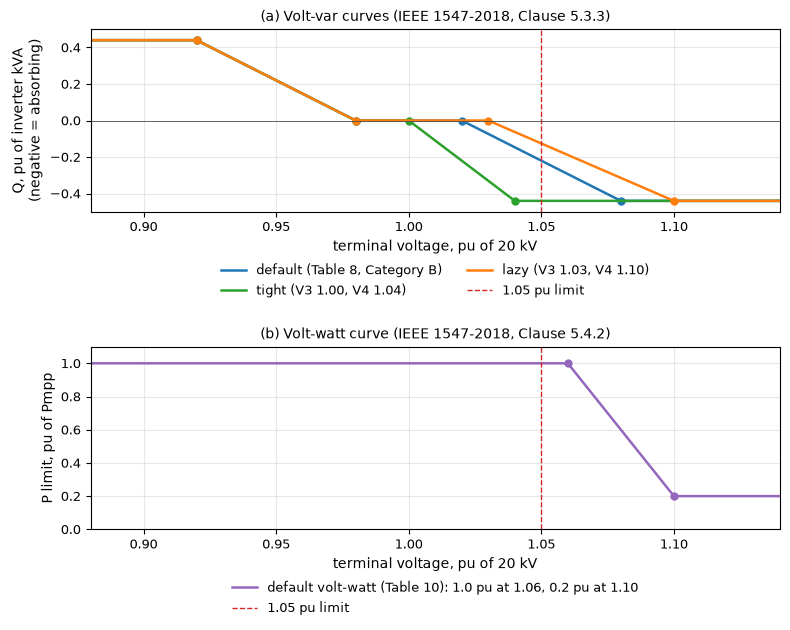

default (Table 8, Category B)    Q = 0 up to 1.02 pu, clamp -0.44 pu of kVA reached at 1.08 pu, slope 7.3 pu of kVA per pu of voltage; Q at 1.05 pu: -0.220
tight (V3 1.00, V4 1.04)         Q = 0 up to 1.00 pu, clamp -0.44 pu of kVA reached at 1.04 pu, slope 11.0 pu of kVA per pu of voltage; Q at 1.05 pu: -0.440
lazy (V3 1.03, V4 1.10)          Q = 0 up to 1.03 pu, clamp -0.44 pu of kVA reached at 1.10 pu, slope 6.3 pu of kVA per pu of voltage; Q at 1.05 pu: -0.126


In [2]:
VV_DEFAULT = ((0.92, 0.98, 1.02, 1.08), (0.44, 0.0, 0.0, -0.44))
VV_TIGHT = ((0.92, 0.98, 1.00, 1.04), (0.44, 0.0, 0.0, -0.44))
VV_LAZY = ((0.92, 0.98, 1.03, 1.10), (0.44, 0.0, 0.0, -0.44))
VW_DEFAULT = ((0.5, 1.06, 1.10, 1.5), (1.0, 1.0, 0.2, 0.2))
CURVES = {"default (Table 8, Category B)": VV_DEFAULT, "tight (V3 1.00, V4 1.04)": VV_TIGHT, "lazy (V3 1.03, V4 1.10)": VV_LAZY}
CURVE_COLORS = {"default (Table 8, Category B)": "tab:blue", "tight (V3 1.00, V4 1.04)": "tab:green", "lazy (V3 1.03, V4 1.10)": "tab:orange"}

vgrid = np.linspace(0.88, 1.14, 261)
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5))
ax = axes[0]
for lab, (x, y) in CURVES.items():
    ax.plot(vgrid, np.interp(vgrid, x, y), color=CURVE_COLORS[lab], lw=1.8, label=lab)
    ax.plot(x, y, "o", color=CURVE_COLORS[lab], ms=5)
ax.axvline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu limit")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xlim(0.88, 1.14); ax.set_ylim(-0.5, 0.5); ax.grid(alpha=0.3)
ax.set_xlabel("terminal voltage, pu of 20 kV"); ax.set_ylabel("Q, pu of inverter kVA\n(negative = absorbing)")
ax.set_title("(a) Volt-var curves (IEEE 1547-2018, Clause 5.3.3)")
legend_below(ax, ncol=2, dy=-0.22)
ax = axes[1]
ax.plot(vgrid, np.interp(vgrid, *VW_DEFAULT), color="tab:purple", lw=1.8, label="default volt-watt (Table 10): 1.0 pu at 1.06, 0.2 pu at 1.10")
ax.plot(VW_DEFAULT[0][1:3], VW_DEFAULT[1][1:3], "o", color="tab:purple", ms=5)
ax.axvline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu limit")
ax.set_xlim(0.88, 1.14); ax.set_ylim(0, 1.1); ax.grid(alpha=0.3)
ax.set_xlabel("terminal voltage, pu of 20 kV"); ax.set_ylabel("P limit, pu of Pmpp")
ax.set_title("(b) Volt-watt curve (IEEE 1547-2018, Clause 5.4.2)")
legend_below(ax, ncol=1, dy=-0.22)
plt.tight_layout(); plt.show()

for lab, (x, y) in CURVES.items():
    print(f"{lab:32s} Q = 0 up to {x[2]:.2f} pu, clamp -0.44 pu of kVA reached at {x[3]:.2f} pu, "
          f"slope {0.44 / (x[3] - x[2]):.1f} pu of kVA per pu of voltage; Q at 1.05 pu: {np.interp(1.05, x, y):+.3f}")

## 2. The KPIs

`kpi.compute_kpis` scores a run from its per-step arrays (voltage of buses 1 to 11,
P and Q of the nine units, the available PV power, the circuit losses, the failure
flag), with $\Delta t = 0.25$ h:

- **hours outside the band**: hours with at least one bus of 1 to 11 above 1.05 pu or
  below 0.95 pu (the two parts are also kept separately);
- **VPI**, the voltage performance index, $\sum_\text{steps}\sum_\text{buses}
  \max(0,\,V - 1.05,\,0.95 - V)\,\Delta t$ in pu h, which weighs a violation by its depth;
- **losses** in MWh, from `dss.Circuit.Losses()` (the whole circuit: both feeders and
  both transformers);
- **curtailed PV** in MWh, $\sum (P_\mathrm{mpp}\,\mathrm{irradiance} - P)\,\Delta t$, where
  the available power is taken as zero below the inverter cut-in of `cigre_dss.add_pv`
  (0.1 % of kVA), so that a unit that is simply off at dawn or dusk does not count as
  curtailed;
- **reactive energy absorbed** ($Q < 0$) and **injected** ($Q > 0$) in Mvarh, kept
  separately because a controller that absorbs to hold the upper limit and one that
  injects to reduce losses would otherwise look alike in $\sum |Q|\,\Delta t$;
- **control-loop failures**, the number of steps at which OpenDSS hit `maxcontroliter`;
- **Vmax / Vmin**, the extreme feeder-1 voltages of the period.

`kpi.kpis_of(result, mask)` applies this to a `simulate.YearResult` or to a subset of
its steps, and `kpi.kpi_table` / `kpi.format_table` lay the results out per controller.

In [3]:
print(f"{'key':26s} {'meaning':34s}")
for k in kpi.KPI_COLUMNS:
    print(f"{k:26s} {kpi.KPI_LABELS[k]:34s}")

key                        meaning                           
hours_violation            hours outside 0.95-1.05 pu        
hours_over                 hours above 1.05 pu               
hours_under                hours below 0.95 pu               
vpi                        VPI, pu.h                         
losses_mwh                 losses, MWh                       
curtailed_mwh              curtailed PV, MWh                 
reactive_mvarh             reactive energy, Mvarh            
reactive_absorbed_mvarh    reactive energy absorbed, Mvarh   
reactive_injected_mvarh    reactive energy injected, Mvarh   
pv_energy_mwh              PV energy, MWh                    
n_fail                     control-loop failures             
vmax                       max voltage, pu                   
vmin                       min voltage, pu                   
hours                      period, h                         


## 3. The simulation loop

`simulate.run_year(controller_setup_fn, steps)` is the loop of notebook 03 packaged for
controllers. The circuit is built once (`simulate.build`: radial feeder 1, the nine PV
units at kVA = 1.1 Pmpp, TR1 at +4.375 %, `controlmode=static`, `maxcontroliter=200`),
then `controller_setup_fn` is called: it either adds OpenDSS control elements (XYCurve
and InvControl) and returns nothing, or returns a Python function that is called before
the solve of every step and sets the kvar setpoint of each unit (the OPF of step 7, and
later the learned policies). For every step of the year, or of the subset `steps`, the
loop scales the two load sectors to their profile values, sets the irradiance of each
unit, calls the per-step function if there is one, solves, and records the voltage of
buses 1 to 11, the P and Q of the nine units and the total circuit losses. The solve
re-holds bus 0 at 110 kV as `cigre_dss.solve` does, with three source iterations instead
of six because the previous step's source setting is a good start. Voltages are read as
one vector (`AllBusMagPu`) and indexed rather than bus by bus, which is what makes a
full year of 35,040 steps a matter of seconds. If the OpenDSS control loop hits
`maxcontroliter`, the engine raises an exception; the loop catches it, counts the step as
a control-loop failure and keeps the last solution.

The cell below runs the worst day without control and compares the per-step maximum
voltage with the screening series of notebook 03, which used `cigre_dss.solve` and the
bus-by-bus readers.

In [4]:
w0 = sel["worst_day_index"] * SPD
steps_worst = np.arange(w0, w0 + SPD)
r_chk = sim.run_year(None, steps_worst, pv, loads, label="no control, worst day")
with h5py.File("screening_2023.h5", "r") as f:
    vmax_screen = f["vmax"][w0:w0 + SPD]
dv = np.abs(r_chk.v.max(axis=1) - vmax_screen).max()
print(f"worst day {DAY_WORST}: max |vmax(loop) - vmax(notebook 03 screening)| = {dv:.1e} pu")
assert dv < 1e-6

no control, worst day       : 96 steps in    0.0 s (0.25 ms per step), control-loop failures 0
worst day 2023-07-22: max |vmax(loop) - vmax(notebook 03 screening)| = 1.8e-09 pu


## 4. Controllers B0 to B4 over the full year

The five fixed controllers of the table in the introduction, each over all 35,040 steps
of the year. B0 has no control element; B1, B3 and B4 are one volt-var InvControl with
the default, tight and lazy curve of step 1; B2 is the combined volt-var/volt-watt
element with the default curves. The runtime of each run is printed by the loop. B0 must
reproduce the screening of notebook 03 exactly (199.75 h above 1.05 pu, the same annual
maximum), which is checked in one line. Because the volt-watt corner of B2 (1.06 pu) is
not expected to be reached once the volt-var curve holds the voltage, the same element is
also run on the worst-day noon step with the corner lowered to 1.03 pu, where it must
curtail, to confirm that `combimode=VV_VW` is wired correctly.

In [5]:
def setup_B0():
    return None
def setup_B1():
    sim.add_voltvar(*VV_DEFAULT, name="vv_default")
def setup_B2():
    sim.add_voltvar_voltwatt(*VV_DEFAULT, *VW_DEFAULT, name="vvvw_default")
def setup_B3():
    sim.add_voltvar(*VV_TIGHT, name="vv_tight")
def setup_B4():
    sim.add_voltvar(*VV_LAZY, name="vv_lazy")

FIXED = {"B0 unity pf": setup_B0, "B1 default volt-var": setup_B1, "B2 volt-var + volt-watt": setup_B2,
         "B3 tight volt-var": setup_B3, "B4 lazy volt-var": setup_B4}
COLORS = {"B0 unity pf": "0.55", "B1 default volt-var": "tab:blue", "B2 volt-var + volt-watt": "tab:cyan",
          "B3 tight volt-var": "tab:green", "B4 lazy volt-var": "tab:orange", "B5 per-step OPF": "tab:red"}
STYLES = {"B2 volt-var + volt-watt": ":"}
SHORT = {n: n.split()[0] for n in COLORS}

results = {}
t_all = time.perf_counter()
for name, fn in FIXED.items():
    results[name] = sim.run_year(fn, None, pv, loads, label=name)
print(f"five full-year runs in {time.perf_counter() - t_all:.0f} s")

kpis_year = {n: kpi.kpis_of(r) for n, r in results.items()}
k0 = kpis_year["B0 unity pf"]
assert k0["hours_over"] == sel["hours_over_1p05_unity_pf"] and abs(k0["vmax"] - sel["vmax_year"]) < 1e-6
print(f"B0 reproduces the notebook-03 screening: {k0['hours_over']:.2f} h above 1.05 pu, Vmax {k0['vmax']:.4f} pu")

COLS = ["hours_violation", "vpi", "losses_mwh", "curtailed_mwh", "reactive_absorbed_mvarh", "reactive_injected_mvarh",
        "n_fail", "vmax", "vmin"]
HEAD = {"hours_violation": "h_outside", "vpi": "VPI_puh", "losses_mwh": "loss_MWh", "curtailed_mwh": "curt_MWh",
        "reactive_absorbed_mvarh": "Qabs_Mvarh", "reactive_injected_mvarh": "Qinj_Mvarh", "n_fail": "fail",
        "vmax": "Vmax", "vmin": "Vmin"}
def show(kp):
    print(kpi.format_table(kpi.kpi_table(kp, COLS)).replace("hours_violation", "h_outside").replace("vpi", "VPI_puh")
          .replace("losses_mwh", "loss_MWh").replace("curtailed_mwh", "curt_MWh").replace("reactive_absorbed_mvarh", "Qabs_Mvarh")
          .replace("reactive_injected_mvarh", "Qinj_Mvarh").replace("n_fail", "fail").replace("vmax", "Vmax").replace("vmin", "Vmin"))
print(f"\nKPIs over the full year {YEAR} ({T} steps), TR1 tap +{TR1_TAP} %:")
show(kpis_year)

# the combined element with the volt-watt corner lowered to 1.03 pu on the worst-day noon step
i_noon = w0 + SPD // 2
def setup_vw_low():
    sim.add_voltvar_voltwatt(*VV_DEFAULT, (0.5, 1.03, 1.07, 1.5), (1.0, 1.0, 0.2, 0.2), name="vvvw_low")
r_low = sim.run_year(setup_vw_low, [i_noon], pv, loads, verbose=False)
r_b2 = results["B2 volt-var + volt-watt"]; kk = np.where(r_b2.steps == i_noon)[0][0]
print(f"\ncombimode check at {pv.index[i_noon]}: B2 (corner 1.06 pu) delivers {r_b2.p_kw[kk].sum():.0f} of {r_b2.p_avail_kw[kk].sum():.0f} kW available, "
      f"max V {r_b2.v[kk].max():.4f} pu; with the corner at 1.03 pu the same element delivers {r_low.p_kw.sum():.0f} kW, max V {r_low.v.max():.4f} pu")
assert r_low.p_kw.sum() < 0.98 * r_low.p_avail_kw.sum()

B0 unity pf                 : 35040 steps in    8.5 s (0.24 ms per step), control-loop failures 0


B1 default volt-var         : 35040 steps in   13.9 s (0.40 ms per step), control-loop failures 0


B2 volt-var + volt-watt     : 35040 steps in   33.7 s (0.96 ms per step), control-loop failures 0


B3 tight volt-var           : 35040 steps in   16.1 s (0.46 ms per step), control-loop failures 0


B4 lazy volt-var            : 35040 steps in   12.7 s (0.36 ms per step), control-loop failures 0
five full-year runs in 85 s
B0 reproduces the notebook-03 screening: 199.75 h above 1.05 pu, Vmax 1.0637 pu

KPIs over the full year 2023 (35040 steps), TR1 tap +4.375 %:
                        h_outside        VPI_puh loss_MWh curt_MWh Qabs_Mvarh Qinj_Mvarh     fail       Vmax       Vmin
B0 unity pf                      199.75     3.9947     383.74         0.000                    0.00                    0.00          0     1.0637     0.9620
B1 default volt-var                0.00     0.0000     395.52         0.000                 1040.40                   41.12          0     1.0421     0.9707
B2 volt-var + volt-watt            0.00     0.0000     395.52         0.000                 1040.43                   41.13          0     1.0421     0.9707
B3 tight volt-var                  0.00     0.0000     453.15         0.000                 4272.39                   41.13          0     1

Reading the table: B0 has the 199.75 PV-caused hours above 1.05 pu of the year, none
below 0.95 pu. Every curve removes them all, so the differences are entirely in the
cost: the default curve absorbs about 1040 Mvarh over the year and raises the losses by
about 12 MWh (3 %) over no control; the tight curve absorbs four times as much and adds
18 % to the losses, for the same zero hours; the lazy curve holds the limit (annual
maximum 1.0485 pu) with about 294 Mvarh, less than a third of the default, and about
4 MWh of extra losses. B2 equals B1 to within the control tolerance: with the volt-var
curve active the voltage never reaches the volt-watt corner, so nothing is curtailed.
The injected reactive energy (about 41 Mvarh) is the same for all four curves, since it
comes from the common lower half of the curve below 0.98 pu at heavy load, where nothing
is below 0.95 pu anyway. The exact values are in the table above.

## 5. The year in figures

(a) Duration curves of the per-step maximum voltage of feeder 1 (the values sorted from
the highest downwards against the number of hours) for B0 to B4, with the 1.05 pu limit;
(b) the first 500 hours, where the curves differ; (c) the reactive energy absorbed per
day by the nine units for B1, B3 and B4 through the year.

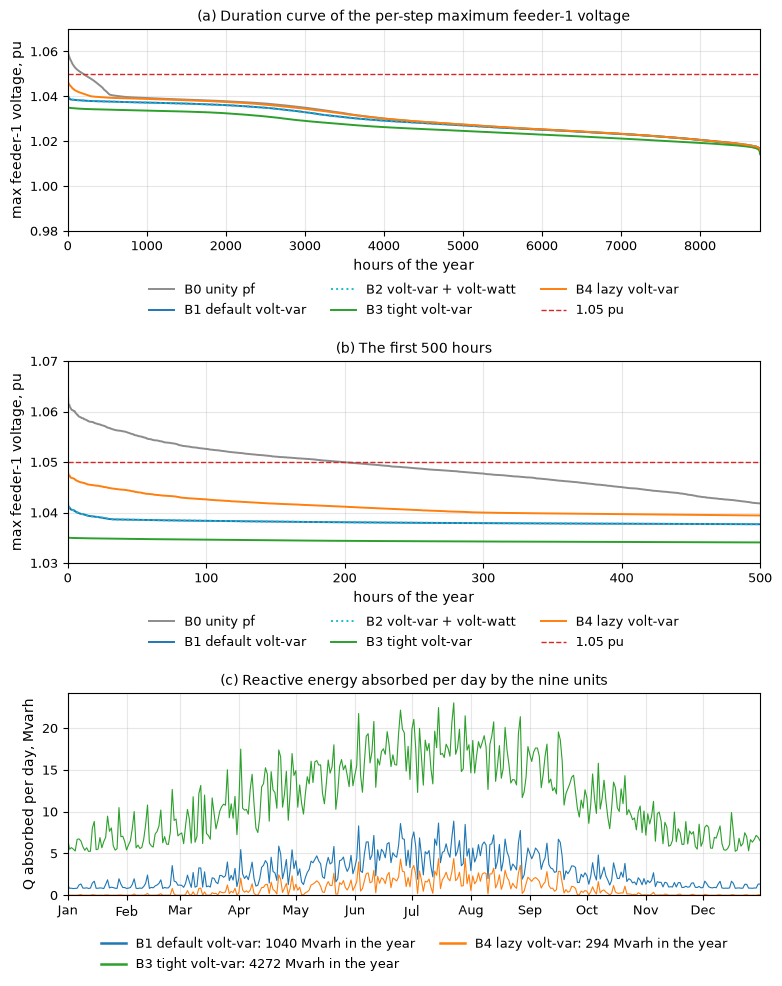

B1 default volt-var     : absorbs on 365 days, up to 8.9 Mvarh per day (on 2023-07-23); steps with any unit absorbing: 3690 h
B3 tight volt-var       : absorbs on 365 days, up to 23.0 Mvarh per day (on 2023-07-23); steps with any unit absorbing: 6530 h
B4 lazy volt-var        : absorbs on 277 days, up to 4.4 Mvarh per day (on 2023-07-29); steps with any unit absorbing: 1778 h


In [6]:
hours_axis = np.arange(1, T + 1) * DT_H
q_daily = {n: pd.Series(-np.minimum(r.q_kvar, 0).sum(axis=1) * DT_H / 1e3, index=r.index).resample("D").sum()
           for n, r in results.items()}

fig, axes = plt.subplots(3, 1, figsize=(8, 10))
for ax, (xmax, ylim, lab) in zip(axes[:2], ((8760, (0.98, 1.07), "(a) Duration curve of the per-step maximum feeder-1 voltage"),
                                           (500, (1.03, 1.07), "(b) The first 500 hours"))):
    for name, r in results.items():
        vs = np.sort(r.v.max(axis=1))[::-1]
        ax.plot(hours_axis, vs, color=COLORS[name], ls=STYLES.get(name, "-"), lw=1.4, label=name)
    ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
    ax.set_xlim(0, xmax); ax.set_ylim(*ylim); ax.grid(alpha=0.3)
    ax.set_xlabel("hours of the year"); ax.set_ylabel("max feeder-1 voltage, pu"); ax.set_title(lab)
legend_below(axes[0], ncol=3, dy=-0.2)
legend_below(axes[1], ncol=3, dy=-0.2)
ax = axes[2]; handles = []
for name in ("B1 default volt-var", "B3 tight volt-var", "B4 lazy volt-var"):
    s = q_daily[name]
    ax.plot(s.index, s.values, color=COLORS[name], lw=0.8)
    handles.append(Line2D([], [], color=COLORS[name], lw=1.8, label=f"{name}: {s.sum():.0f} Mvarh in the year"))
ax.set_xlim(pd.Timestamp(f"{YEAR}-01-01"), pd.Timestamp(f"{YEAR}-12-31")); ax.set_xticks(MONTH_DATES); ax.set_xticklabels(MONTHS)
ax.set_ylabel("Q absorbed per day, Mvarh"); ax.set_ylim(0, None); ax.grid(alpha=0.3)
ax.set_title("(c) Reactive energy absorbed per day by the nine units")
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout(); plt.show()

for name in ("B1 default volt-var", "B3 tight volt-var", "B4 lazy volt-var"):
    s = q_daily[name]
    print(f"{name:24s}: absorbs on {(s > 0.01).sum()} days, up to {s.max():.1f} Mvarh per day (on {s.idxmax().date()}); "
          f"steps with any unit absorbing: {(results[name].q_kvar < -1).any(axis=1).sum() * DT_H:.0f} h")

## 6. The worst day, 2023-07-22

The worst day of the screening (a clear Saturday in July with the weekend load), hour by
hour. (a) The voltage at the bus that carries the highest B0 voltage of the day, for B0
to B4, with the 1.05 pu limit; (b) the total reactive power of the nine units for B1, B3
and B4 (negative = absorbing); (c) the total PV power available and delivered for B2,
which shows whether the volt-watt part ever curtails.

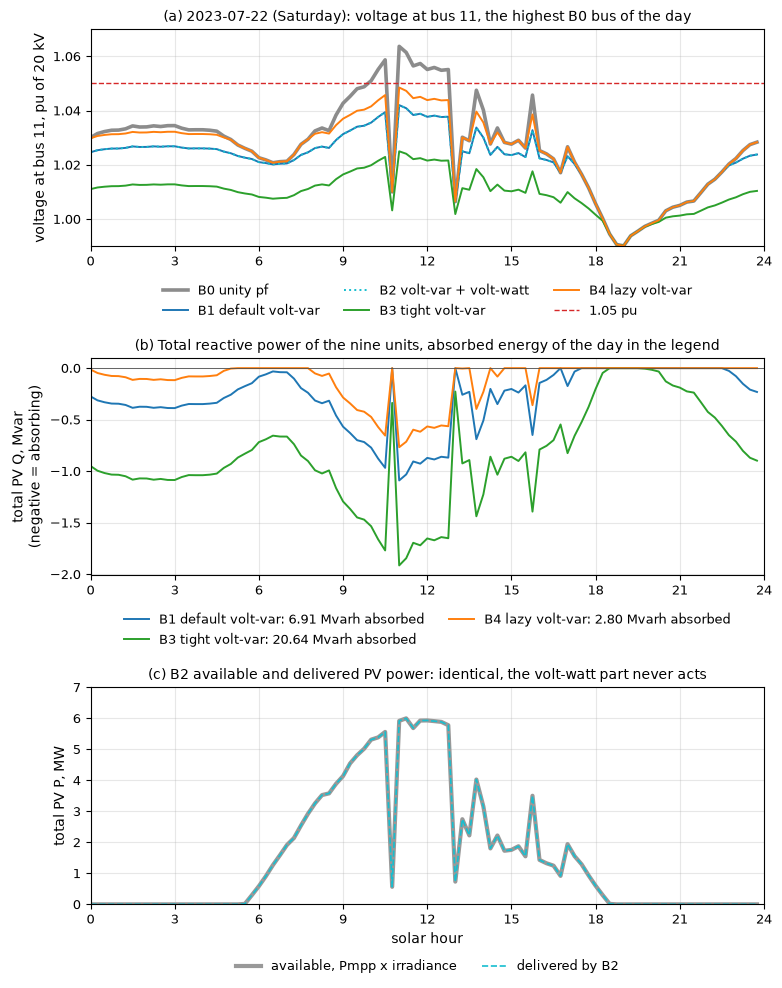

B0 unity pf              max V 1.0637 pu, hours outside band  2.75, Q absorbed   0.00 Mvarh, curtailed 0.000 MWh, losses 0.866 MWh
B1 default volt-var      max V 1.0421 pu, hours outside band  0.00, Q absorbed   6.91 Mvarh, curtailed 0.000 MWh, losses 0.961 MWh
B2 volt-var + volt-watt  max V 1.0421 pu, hours outside band  0.00, Q absorbed   6.91 Mvarh, curtailed 0.000 MWh, losses 0.961 MWh
B3 tight volt-var        max V 1.0349 pu, hours outside band  0.00, Q absorbed  20.64 Mvarh, curtailed 0.000 MWh, losses 1.244 MWh
B4 lazy volt-var         max V 1.0485 pu, hours outside band  0.00, Q absorbed   2.80 Mvarh, curtailed 0.000 MWh, losses 0.908 MWh


In [7]:
r0d = results["B0 unity pf"].subset(results["B0 unity pf"].day_mask(DAY_WORST))
b_worst = F1[int(np.argmax(r0d.v.max(axis=0)))]
jb = F1.index(b_worst)
day = {n: r.subset(r.day_mask(DAY_WORST)) for n, r in results.items()}
rb2 = day["B2 volt-var + volt-watt"]
curt_b2 = np.maximum(0.0, rb2.p_avail_kw - rb2.p_kw).sum() * DT_H / 1e3

fig, axes = plt.subplots(3, 1, figsize=(8, 10))
ax = axes[0]
for name, rd in day.items():
    ax.plot(h, rd.v[:, jb], color=COLORS[name], ls=STYLES.get(name, "-"), lw=2.6 if name == "B0 unity pf" else 1.4, label=name)
ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0.99, 1.07); ax.grid(alpha=0.3)
ax.set_ylabel(f"voltage at bus {b_worst}, pu of 20 kV")
ax.set_title(f"(a) {DAY_WORST} ({pd.Timestamp(DAY_WORST).day_name()}): voltage at bus {b_worst}, the highest B0 bus of the day")
legend_below(ax, ncol=3, dy=-0.12)
ax = axes[1]
for name in ("B1 default volt-var", "B3 tight volt-var", "B4 lazy volt-var"):
    rd = day[name]
    ax.plot(h, rd.q_kvar.sum(axis=1) / 1e3, color=COLORS[name], lw=1.4,
            label=f"{name}: {-np.minimum(rd.q_kvar, 0).sum() * DT_H / 1e3:.2f} Mvarh absorbed")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.grid(alpha=0.3)
ax.set_ylabel("total PV Q, Mvar\n(negative = absorbing)"); ax.set_title("(b) Total reactive power of the nine units, absorbed energy of the day in the legend")
legend_below(ax, ncol=2, dy=-0.12)
ax = axes[2]
ax.plot(h, rb2.p_avail_kw.sum(axis=1) / 1e3, color="0.6", lw=3, label="available, Pmpp x irradiance")
ax.plot(h, rb2.p_kw.sum(axis=1) / 1e3, color=COLORS["B2 volt-var + volt-watt"], lw=1.2, ls="--", label="delivered by B2")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0, 7); ax.grid(alpha=0.3)
ax.set_xlabel("solar hour"); ax.set_ylabel("total PV P, MW")
ax.set_title("(c) B2 available and delivered PV power" + (": identical, the volt-watt part never acts" if curt_b2 < 1e-3 else f": {curt_b2:.3f} MWh curtailed"))
legend_below(ax, ncol=2, dy=-0.2)
plt.tight_layout(); plt.show()

for name, rd in day.items():
    k = kpi.kpis_of(rd)
    print(f"{name:24s} max V {k['vmax']:.4f} pu, hours outside band {k['hours_violation']:5.2f}, Q absorbed {k['reactive_absorbed_mvarh']:6.2f} Mvarh, "
          f"curtailed {k['curtailed_mwh']:.3f} MWh, losses {k['losses_mwh']:.3f} MWh")

The curves start absorbing as soon as the terminal voltage leaves their dead band, hours
before the limit would be reached, and keep absorbing through the whole sunny period. The
tight curve is at work from early morning; the default curve from 1.02 pu; the lazy curve
only around midday, holding bus 11 just under the limit, which is the shape that a
controller aiming at the limit rather than at nominal voltage would produce. On this day
no curve curtails.

## 7. The OPF bound B5

At every step the nine reactive setpoints $q_j$ are chosen to minimise

$$
J(q) = P_\mathrm{loss}(q)\;[\mathrm{kW}] \;+\; K_p\, N_\mathrm{viol}(q) \;+\; w_q \sum_j |q_j|\;[\mathrm{kvar}],
\qquad q_j \in [-0.44,\, +0.44]\,\mathrm{kVA}_j,
$$

with $K_p = 1000$, $N_\mathrm{viol}$ the number of buses 1 to 11 outside 0.95 to 1.05 pu,
and $w_q = 0.01$ kW/kvar a small tie-breaker against reactive power that buys nothing
(1 kW per 100 kvar). The form follows Eq. 2 of Wagle et al. (2023, IET GTD). OpenDSS
solves the power flow inside the objective, so every evaluation of $J$ is one snapshot.
$N_\mathrm{viol}$ is a step function that a gradient solver cannot see, so
`simulate.OPFController` solves the equivalent smooth problem, minimise
$P_\mathrm{loss} + w_q \sum \sqrt{q_j^2 + 1}$ subject to $0.95 \le V_b \le 1.05$ as
inequality constraints, with `scipy.optimize.minimize` (SLSQP, finite-difference
gradients, variables in pu of kVA) from a warm start at the previous step's setpoint; if
the constrained solve does not succeed or still violates a limit, a hinge-penalty form is
solved as a fallback. The candidates (warm start, $q = 0$, the SLSQP results) are then
scored with $J$ itself and the best is applied, so the applied setpoint is never worse
than doing nothing. The controller logs $J$, the number of power flows and the time of
every step; it needs about 60 power flows and some 12 to 15 ms per step on average.

B5 knows every bus voltage of the feeder and re-optimises every 15 minutes; it is not a
controller that could be deployed, but the bound on what the nine reactive setpoints can
achieve with this objective. It is run on **32 sampled days**: the worst day, the typical
day, and 30 further days drawn at random with seed 0 (3072 steps). B0 to B4 are scored on
exactly those days for comparison, which is the only fair table that includes B5.

In [8]:
rng = np.random.default_rng(0)
others = [d for d in range(365) if d not in (sel["worst_day_index"], sel["typical_day_index"])]
SAMPLE_DAYS = sorted([sel["worst_day_index"], sel["typical_day_index"]] + [int(x) for x in rng.choice(others, 30, replace=False)])
steps_sample = np.concatenate([np.arange(d * SPD, (d + 1) * SPD) for d in SAMPLE_DAYS])
sample_dates = [str((pd.Timestamp(f"{YEAR}-01-01") + pd.Timedelta(days=d)).date()) for d in SAMPLE_DAYS]
print(f"sampled days ({len(SAMPLE_DAYS)}, {len(steps_sample)} steps): " + ", ".join(sample_dates))

opf = sim.OPFController(w_q=0.01, w_viol=1000.0, q_max_pu=0.44)
results["B5 per-step OPF"] = sim.run_year(opf, steps_sample, pv, loads, label="B5 per-step OPF (sampled days)")
opf_log = pd.DataFrame(opf.log)
print(f"OPF solver: SLSQP, warm start; power flows per step median {opf_log.n_pf.median():.0f} (max {opf_log.n_pf.max()}), "
      f"time per step mean {opf_log.time_s.mean() * 1e3:.1f} ms (max {opf_log.time_s.max() * 1e3:.0f} ms); "
      f"constrained solve succeeded on {(opf_log.method == 'constrained').mean():.1%} of steps; "
      f"applied candidate: {opf_log.chosen.value_counts().to_dict()}")

mask_sample = np.zeros(T, dtype=bool); mask_sample[steps_sample] = True
kpis_sample = {n: (kpi.kpis_of(r, mask_sample[r.steps]) if n != "B5 per-step OPF" else kpi.kpis_of(r)) for n, r in results.items()}
print(f"\nKPIs over the {len(SAMPLE_DAYS)} sampled days ({len(steps_sample)} steps), the only period on which B5 was run:")
show(kpis_sample)

k1, k5 = kpis_sample["B1 default volt-var"], kpis_sample["B5 per-step OPF"]
r5 = results["B5 per-step OPF"]; night = r5.irr.max(axis=1) == 0
print(f"\nB5 against B1 on the sampled days: Q absorbed {k5['reactive_absorbed_mvarh']:.1f} against {k1['reactive_absorbed_mvarh']:.1f} Mvarh "
      f"({k1['reactive_absorbed_mvarh'] / k5['reactive_absorbed_mvarh']:.0f} times less), losses {k5['losses_mwh']:.2f} against {k1['losses_mwh']:.2f} MWh "
      f"({100 * (k5['losses_mwh'] / k1['losses_mwh'] - 1):+.1f} %); B5 injects {k5['reactive_injected_mvarh']:.1f} Mvarh, "
      f"of which {r5.q_kvar[night][r5.q_kvar[night] > 0].sum() * DT_H / 1e3:.1f} Mvarh at night (no PV output)")

sampled days (32, 3072 steps): 2023-01-01, 2023-01-06, 2023-01-13, 2023-01-14, 2023-01-26, 2023-03-01, 2023-04-01, 2023-04-09, 2023-04-15, 2023-05-22, 2023-06-21, 2023-06-24, 2023-07-10, 2023-07-17, 2023-07-19, 2023-07-22, 2023-07-31, 2023-08-03, 2023-08-11, 2023-08-13, 2023-08-28, 2023-09-13, 2023-09-14, 2023-09-24, 2023-10-06, 2023-10-08, 2023-10-14, 2023-10-19, 2023-11-06, 2023-11-13, 2023-11-29, 2023-12-06


B5 per-step OPF (sampled days): 3072 steps in   46.4 s (15.11 ms per step), control-loop failures 0
OPF solver: SLSQP, warm start; power flows per step median 60 (max 1204), time per step mean 14.7 ms (max 212 ms); constrained solve succeeded on 99.8% of steps; applied candidate: {'slsqp': 1594, 'zero': 1349, 'warm': 123, 'penalty': 6}

KPIs over the 32 sampled days (3072 steps), the only period on which B5 was run:
                        h_outside        VPI_puh loss_MWh curt_MWh Qabs_Mvarh Qinj_Mvarh     fail       Vmax       Vmin
B0 unity pf                       24.75     0.5208      32.83         0.000                    0.00                    0.00          0     1.0637     0.9627
B1 default volt-var                0.00     0.0000      33.94         0.000                   97.12                    3.61          0     1.0421     0.9710
B2 volt-var + volt-watt            0.00     0.0000      33.94         0.000                   97.12                    3.61          0     1.0421 

On the sampled days B5 also removes every violation hour, with the lowest losses of all
controllers. Its reactive energy is of a different kind: it absorbs only the small amount
needed to hold the limit and *injects* the rest during load hours, including at night,
to reduce losses; that injection is a consequence of putting losses and kvar in one
objective with a small kvar weight, not of the voltage problem. On the voltage problem
alone the comparison is between the absorbed parts, and the default curve absorbs about
nineteen times what the bound needs to hold the same limit.

## 8. B1 against B5 on the worst day

First figure: (a) the voltage at the highest B0 bus of the day and (b) the total reactive
power of the nine units, B1 against B5, with B0 for reference. The OPF does nothing until
the limit is threatened and then absorbs just enough to hold the worst bus at 1.05 pu,
which is visible as the flat top of its voltage trace.

Second figure: the reactive power of each unit at 12:00 on the worst day, B1 against
B5, in pu of the inverter kVA, with the units ordered by their distance from the
substation. The distance is the length of the radial path from bus 1 (the TR1 secondary)
to the unit's bus, summed over the segment lengths of the data file with the tie
segments open. The default curve responds to the local voltage, and because the PV buses
of this feeder all sit within a few tenths of a per cent of each other at full output
(notebook 02), it asks every unit for nearly the same Q; the OPF places the reactive
power where a kvar moves the constraining bus the most and costs the fewest losses,
which is at the far ends of the feeder.

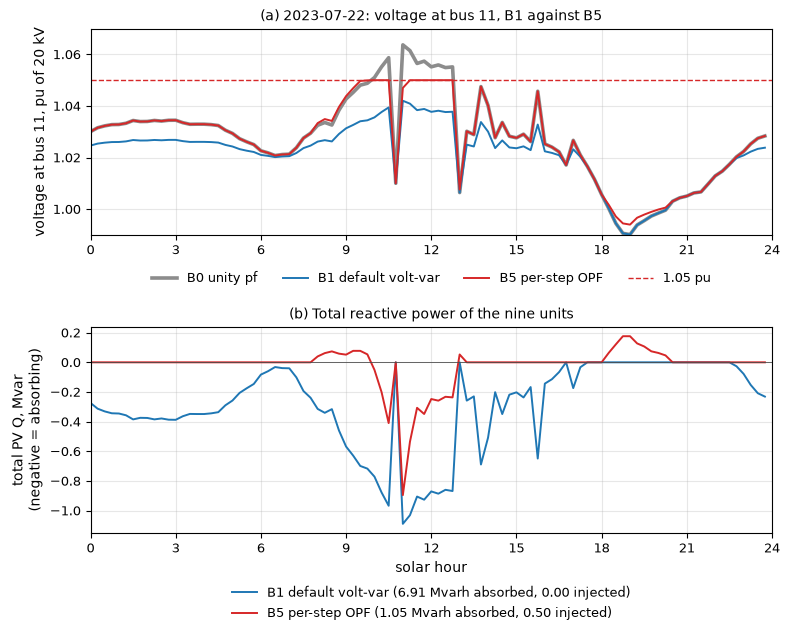

In [9]:
r1d, r5d = day["B1 default volt-var"], results["B5 per-step OPF"].subset(results["B5 per-step OPF"].day_mask(DAY_WORST))
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5))
ax = axes[0]
ax.plot(h, r0d.v[:, jb], color=COLORS["B0 unity pf"], lw=2.6, label="B0 unity pf")
ax.plot(h, r1d.v[:, jb], color=COLORS["B1 default volt-var"], lw=1.4, label="B1 default volt-var")
ax.plot(h, r5d.v[:, jb], color=COLORS["B5 per-step OPF"], lw=1.4, label="B5 per-step OPF")
ax.axhline(1.05, color="tab:red", lw=1, ls="--", label="1.05 pu")
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.set_ylim(0.99, 1.07); ax.grid(alpha=0.3)
ax.set_ylabel(f"voltage at bus {b_worst}, pu of 20 kV"); ax.set_title(f"(a) {DAY_WORST}: voltage at bus {b_worst}, B1 against B5")
legend_below(ax, ncol=4, dy=-0.12)
ax = axes[1]
for name, rd in (("B1 default volt-var", r1d), ("B5 per-step OPF", r5d)):
    ax.plot(h, rd.q_kvar.sum(axis=1) / 1e3, color=COLORS[name], lw=1.4,
            label=f"{name} ({-np.minimum(rd.q_kvar, 0).sum() * DT_H / 1e3:.2f} Mvarh absorbed, {np.maximum(rd.q_kvar, 0).sum() * DT_H / 1e3:.2f} injected)")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3)); ax.grid(alpha=0.3)
ax.set_xlabel("solar hour"); ax.set_ylabel("total PV Q, Mvar\n(negative = absorbing)"); ax.set_title("(b) Total reactive power of the nine units")
legend_below(ax, ncol=1, dy=-0.2)
plt.tight_layout(); plt.show()

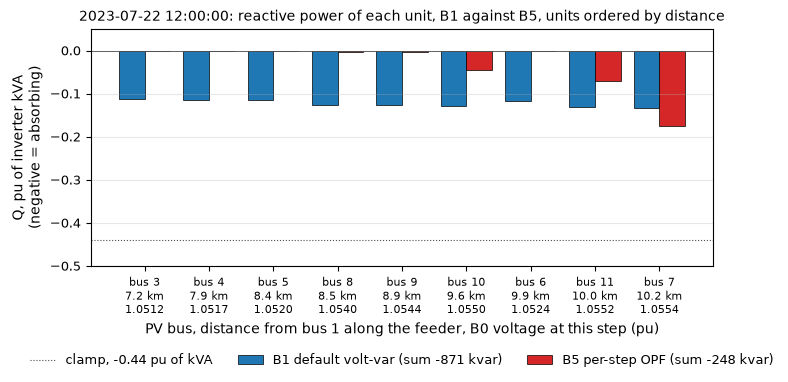

bus              3       4       5       8       9      10       6      11       7
km            7.24    7.85    8.41    8.54    8.86    9.63    9.95    9.96   10.21
B1 Q/kVA    -0.113  -0.115  -0.115  -0.125  -0.127  -0.129  -0.117  -0.130  -0.133
B5 Q/kVA    -0.002  -0.002  -0.002  -0.003  -0.003  -0.044  -0.002  -0.071  -0.175
max feeder-1 voltage at this step: B0 1.0554, B1 1.0381, B5 1.0500 pu; B5 absorbs at buses [10, 11, 7] (96% of its total)


In [10]:
# distance of each bus from bus 1 along the radial feeder (tie segments open)
d = cd.load_data()
open_seg = {s["line_segment"] for s in d["switches"]}
adj = {}
for l in d["lines"]:
    if l["segment"] not in open_seg:
        adj.setdefault(l["from_bus"], []).append((l["to_bus"], l["length_km"]))
        adj.setdefault(l["to_bus"], []).append((l["from_bus"], l["length_km"]))
dist = {1: 0.0}; todo = [1]
while todo:
    b = todo.pop()
    for nb_, km in adj.get(b, []):
        if nb_ not in dist:
            dist[nb_] = dist[b] + km; todo.append(nb_)
order = sorted(PV_BUSES, key=lambda b: dist[b])
jj = [PV_BUSES.index(b) for b in order]

i12 = w0 + SPD // 2
rB1, rB5 = results["B1 default volt-var"], results["B5 per-step OPF"]
qB1 = rB1.q_kvar[np.where(rB1.steps == i12)[0][0]] / PV_KVA
qB5 = rB5.q_kvar[np.where(rB5.steps == i12)[0][0]] / PV_KVA
vB0 = results["B0 unity pf"].v[i12]
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - 0.2, qB1[jj], 0.4, color=COLORS["B1 default volt-var"], edgecolor="black", lw=0.5, label=f"B1 default volt-var (sum {qB1 @ PV_KVA:.0f} kvar)")
ax.bar(x + 0.2, qB5[jj], 0.4, color=COLORS["B5 per-step OPF"], edgecolor="black", lw=0.5, label=f"B5 per-step OPF (sum {qB5 @ PV_KVA:.0f} kvar)")
ax.axhline(-0.44, color="0.3", lw=0.8, ls=":", label="clamp, -0.44 pu of kVA")
ax.axhline(0, color="0.3", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([f"bus {b}\n{dist[b]:.1f} km\n{vB0[F1.index(b)]:.4f}" for b in order], fontsize=8)
ax.set_xlabel("PV bus, distance from bus 1 along the feeder, B0 voltage at this step (pu)")
ax.set_ylabel("Q, pu of inverter kVA\n(negative = absorbing)"); ax.set_ylim(-0.5, 0.05); ax.grid(axis="y", alpha=0.3)
ax.set_title(f"{pv.index[i12]}: reactive power of each unit, B1 against B5, units ordered by distance")
legend_below(ax, ncol=3, dy=-0.32)
plt.tight_layout(); plt.show()

print("bus       " + "".join(f"{b:8d}" for b in order))
print("km        " + "".join(f"{dist[b]:8.2f}" for b in order))
print("B1 Q/kVA  " + "".join(f"{q:8.3f}" for q in qB1[jj]))
print("B5 Q/kVA  " + "".join(f"{q:8.3f}" for q in qB5[jj]))
far = [b for b in order if qB5[PV_BUSES.index(b)] < -0.02]
print(f"max feeder-1 voltage at this step: B0 {vB0.max():.4f}, B1 {rB1.v[i12].max():.4f}, B5 {rB5.v[np.where(rB5.steps == i12)[0][0]].max():.4f} pu; "
      f"B5 absorbs at buses {far} ({-qB5[[PV_BUSES.index(b) for b in far]] @ PV_KVA[[PV_BUSES.index(b) for b in far]] / -(qB5 @ PV_KVA):.0%} of its total)")

## 9. KPI bars

Four KPIs per controller as stacked panels: hours outside the band, losses, reactive
energy absorbed and reactive energy injected. First figure: B0 to B5 on the 32 sampled
days, the only period on which B5 exists; second figure: B0 to B4 on the full year. The
bar labels give the values; values below 0.001 (1 kWh, 1 kvarh) are control-iteration
noise and are labelled 0.

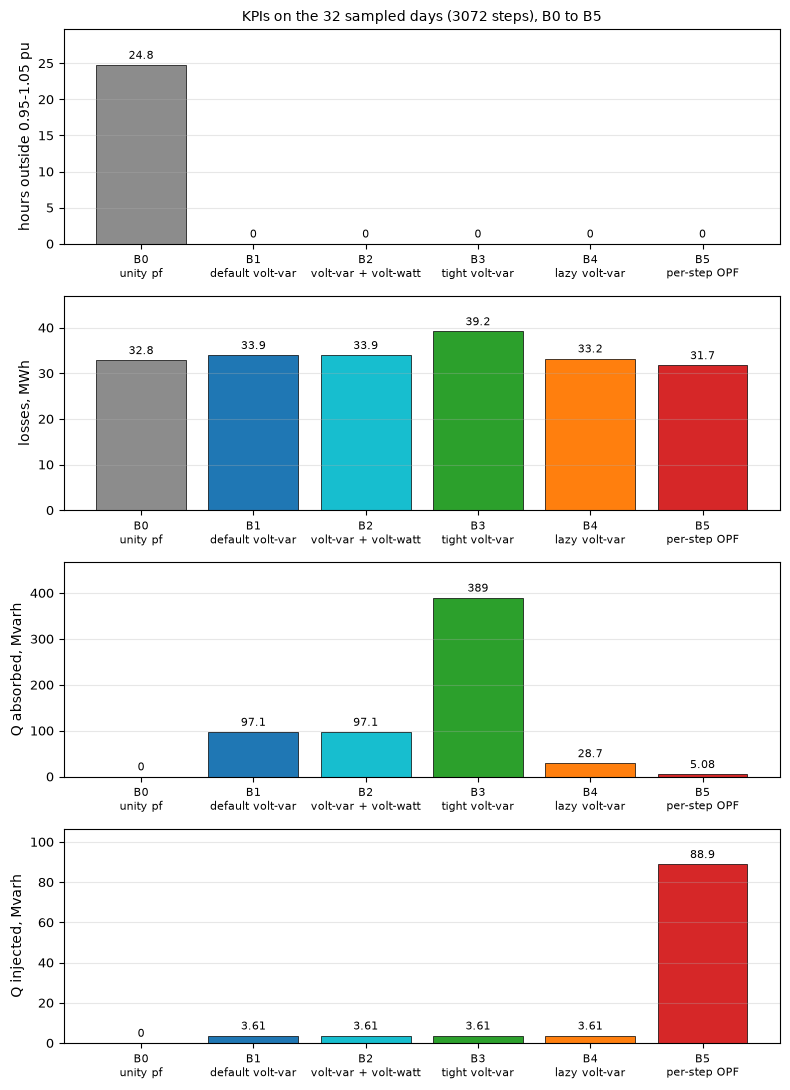

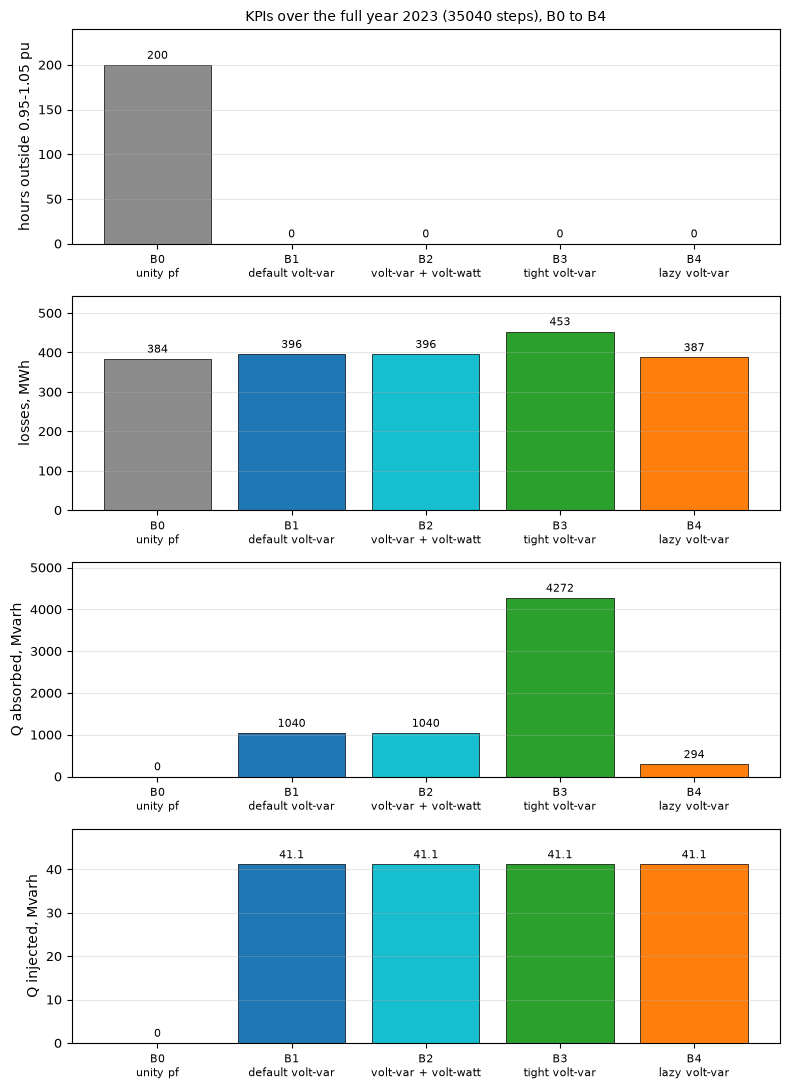

In [11]:
KPI_PLOT = [("hours_violation", "hours outside 0.95-1.05 pu"), ("losses_mwh", "losses, MWh"),
            ("reactive_absorbed_mvarh", "Q absorbed, Mvarh"), ("reactive_injected_mvarh", "Q injected, Mvarh")]

def kpi_bars(kp, title):
    names = list(kp); x = np.arange(len(names))
    fig, axes = plt.subplots(4, 1, figsize=(8, 11))
    for ax, (c, lab) in zip(axes, KPI_PLOT):
        vals = [kp[n][c] for n in names]
        ax.bar(x, vals, color=[COLORS[n] for n in names], edgecolor="black", lw=0.5)
        ymax = max(vals) if max(vals) > 1e-3 else 1.0
        for xi, v in zip(x, vals):
            ax.text(xi, v + 0.02 * ymax, "0" if v < 1e-3 else (f"{v:.0f}" if v >= 100 else f"{v:.3g}"), ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels([n.replace(" ", "\n", 1) for n in names], fontsize=8)
        ax.set_ylim(0, ymax * 1.2); ax.set_ylabel(lab); ax.grid(axis="y", alpha=0.3)
    axes[0].set_title(title)
    plt.tight_layout(); plt.show()

kpi_bars(kpis_sample, f"KPIs on the {len(SAMPLE_DAYS)} sampled days ({len(steps_sample)} steps), B0 to B5")
kpi_bars(kpis_year, f"KPIs over the full year {YEAR} ({T} steps), B0 to B4")

## 10. Save the per-step series and the KPIs

`baselines_2023.h5` holds one group per controller with the step indices, time stamps,
the voltage of buses 1 to 11, P and Q of the nine units, the irradiance, the losses and
the failure flag; the KPIs are group attributes (`kpi_*` for the period of the run,
`kpi_sample_*` for the sampled days), and the OPF log is a table in the B5 group. The
configuration, the curves, the OPF settings, the sampled days, the runtimes and both KPI
tables are also written to `baselines_2023.json`.

In [12]:
runtime = {SHORT[n]: r.runtime_s for n, r in results.items()}
with h5py.File("baselines_2023.h5", "w") as f:
    f.attrs["tr1_tap_pct"] = TR1_TAP; f.attrs["year"] = YEAR; f.attrs["dt_h"] = DT_H; f.attrs["kva_ratio"] = sim.KVA_RATIO
    f.attrs["pv_buses"] = PV_BUSES; f.attrs["pv_kw"] = PV_KW; f.attrs["pv_kva"] = PV_KVA
    f.attrs["f1_buses"] = F1; f.attrs["sample_days"] = SAMPLE_DAYS
    for name, r in results.items():
        g = f.create_group(SHORT[name])
        g.attrs["label"] = name; g.attrs["period"] = "full year" if len(r.steps) == T else "sampled days"
        g.attrs["runtime_s"] = r.runtime_s
        g.create_dataset("steps", data=r.steps); g.create_dataset("time", data=(r.index.asi8 // 10 ** 9).astype(np.int64))
        for k in ("v", "p_kw", "q_kvar", "irr", "losses_kw", "failed"):
            g.create_dataset(k, data=getattr(r, k), compression="gzip")
        g["v"].attrs["description"] = "voltage of buses 1..11 (columns), pu of 20 kV"
        g["q_kvar"].attrs["description"] = "reactive power of the nine PV units (columns, PV_BUSES order), kvar, positive = injecting"
        for k, v in (kpis_year.get(name) or kpis_sample[name]).items():
            g.attrs["kpi_" + k] = v
        for k, v in kpis_sample[name].items():
            g.attrs["kpi_sample_" + k] = v
    f["B5"].create_dataset("opf_log", data=opf_log.drop(columns=["method", "chosen"]).to_records(index=False))
summary = dict(tr1_tap_pct=TR1_TAP, kva_ratio=sim.KVA_RATIO, year=YEAR, dt_h=DT_H,
               controllers={SHORT[n]: n for n in results},
               curves=dict(vv_default=VV_DEFAULT, vv_tight=VV_TIGHT, vv_lazy=VV_LAZY, vw_default=VW_DEFAULT),
               opf=dict(w_q_kw_per_kvar=opf.w_q, w_viol=opf.w_viol, q_max_pu_kva=opf.q_max_pu, solver="SLSQP, warm start",
                        time_per_step_ms=float(opf_log.time_s.mean() * 1e3), power_flows_per_step_median=float(opf_log.n_pf.median())),
               sample_days=SAMPLE_DAYS, sample_dates=sample_dates, worst_day=DAY_WORST, typical_day=DAY_TYPICAL,
               runtime_s=runtime,
               kpis_full_year={SHORT[n]: k for n, k in kpis_year.items()},
               kpis_sampled_days={SHORT[n]: k for n, k in kpis_sample.items()})
with open("baselines_2023.json", "w") as f:
    json.dump(summary, f, indent=2)
with h5py.File("baselines_2023.h5", "r") as f:
    print("baselines_2023.h5 groups:", {g: f[g].attrs["period"] for g in f})
    print("datasets per group:", list(f["B5"]))
print("runtime per controller, s:", {k: round(v, 1) for k, v in runtime.items()})

baselines_2023.h5 groups: {'B0': 'full year', 'B1': 'full year', 'B2': 'full year', 'B3': 'full year', 'B4': 'full year', 'B5': 'sampled days'}
datasets per group: ['failed', 'irr', 'losses_kw', 'opf_log', 'p_kw', 'q_kvar', 'steps', 'time', 'v']
runtime per controller, s: {'B0': 8.5, 'B1': 13.9, 'B2': 33.7, 'B3': 16.1, 'B4': 12.7, 'B5': 46.4}


## 11. Summary

- **How well do the standard curves do?** On violation hours, perfectly: at this tap
  and this PV size (199.75 PV-caused hours above 1.05 pu at unity power factor, VPI about
  4 pu h), the Category B default volt-var curve removes every hour above 1.05 pu, and
  so do the volt-watt variant, the tight curve and the lazy curve. The differences are in
  the cost. The default curve absorbs about 1040 Mvarh in the year and raises the annual
  losses by about 12 MWh (3 %) over unity power factor. The tight curve is the wrong
  direction on this feeder: it quadruples the absorbed reactive energy (about 4270 Mvarh)
  and adds 18 % to the losses for the same zero hours. The lazy curve holds the limit
  with an annual maximum of 1.0485 pu at about 294 Mvarh, less than a third of the
  default, and about 4 MWh of extra losses. Adding the default volt-watt curve changes
  nothing (B2 = B1 to within the control tolerance): once volt-var is active the voltage
  never reaches the 1.06 pu corner, and no PV energy is curtailed anywhere in the year.
- **How far are they from the feeder-wide optimum?** On the 32 sampled days the OPF also
  removes every violation, but needs only about 5 Mvarh of absorption against about 97
  for the default curve (about nineteen times less) and 389 for the tight curve, and its losses
  are about 6 % below those of the default curve (and 3 % below unity power factor, thanks
  to the reactive injection that its loss term buys at night and at heavy load). It
  achieves this by waiting until the limit binds and then drawing about four fifths of
  its absorption from the two far-end units, at bus 7 and at bus 11, whereas the local curve
  asks every unit for nearly the same Q because their terminal voltages are nearly the
  same. The gap between the standard curve and the bound is therefore not in *whether*
  the limit is held but in *where* and *when* the reactive power is spent: the same
  curve at every unit cannot tell the far end of the feeder from its head, and cannot
  tell a sunny weekday from the weekend on which the limit is actually reached.
- **Caveats.** B5 is an upper bound for per-step, full-information reactive dispatch with
  the stated objective, run on 32 days (3072 steps); its small |Q| weight is a choice that
  sets the loss/kvar balance (a larger weight would remove the loss-reducing injection and
  leave the absorption almost unchanged). The curves also lift the minimum voltage, which
  is not needed here since nothing goes below 0.95 pu.

The next notebook builds a learning environment in which each unit's curve points become
adjustable: the same loop, the same year, the same KPIs, with the lazy curve as the fixed
reference and B5 as the bound.

Files: `simulate.py` (`run_year`, `build`, `solve_step`, the InvControl helpers,
`OPFController`, `YearResult`), `kpi.py`, `baselines_2023.h5`, `baselines_2023.json`
and this notebook.